After getting a feel for how the model is set up and how to change parameters in **Tutorial 1**, this will introduce you to the way you can run and save simulations from the command line.

This simulation *will* save data, though we will only still be running small numbers of simulations. Running it on a GPU backend would be preferable and faster, but it will run on CPUs as well. 

In [1]:
# Import packages and set environment variables
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import os
import jax
# 👾 specify JAX devices here if needed

import sparse
from pathlib import Path
from natsort import natsorted
from src.utils.sim_utils import *
from src.utils.plot_utils import *
from src.simulation.vnc_sim import *
from src.utils.path_utils import *
from omegaconf import OmegaConf
from tqdm.auto import tqdm
from src.utils.path_utils import register_custom_resolvers
register_custom_resolvers()

In [2]:
# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

# Run from command line with `run_hydra.py`

First, we will run the experiment `DNg100_test` as-is from the config file. Here, you can see that this specifies 2 replicates (`n_replicates`) of a simulation where DNg100 (neuron `31`) is activated with a stimulus strength of 250. 

In [3]:
# display specifications of the DNg100_test file we'll be running:
convert_dict_to_string(load_from_yaml("../configs/experiment/DNg100_test.yaml"))

{'name': 'DNg100_test',
 'wPath': '${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv',
 'dfPath': '${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv',
 'n_replicates': 2,
 'batch_size': None,
 'dn_screen': False,
 'stimNeurons': [[31]],
 'removeNeurons': [],
 'keepOnly': [],
 'stimI': [[250]],
 'seed': 1,
 'saveFigs': True,
 'useTsp': False,
 'save_checkpoints': False,
 'max_pruning_iterations': 200,
 'oscillation_threshold': 0.5}

To run this from the command line, we will specify this as the experiment, with `starting-paths` as our paths (if you have another .yaml file you would like to use for your paths, substitute it here and in all of the following examples!), and pass these as arguments to the script `run_hydra.py` in `/src`.

These will run directly in the command line. First make sure your terminal window is in the working directory `vnc-connectome-sim` (one level above this notebook), then run the script. The `%run` magic command within Jupyter notebook is equivalent to `python` in the terminal itself.

The `run_id` argument is meant to uniquely specify a simulation that was run. Specifying the same combination of `experiment`, `version`, and `run_id` will lead to the same `save_dir`. When this happens, `run_hydra.py` finds the last checkpoint and resumes the simulation from there. This also means that if the simulation already reached an endpoint it will not run anything.

In [4]:
%cd ..

/home/smpuglie/Pugliese_cpg_2025


In [5]:
%run src/run_hydra.py experiment=DNg100_test run_id=tutorial-2-00 paths=starting-paths

Gpu devices: 2
Logging to: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-00/run_hydra.log
Config saved to /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-00/logs/run_config.yaml
Running VNC simulation with the following configuration:
Execution mode: sync, Pruning: False
Created 1 stimulus configurations
Running baseline simulation with:
  1 stimulus configurations
  2 parameter sets
  4604 neurons
  2001 time points
Calculating optimal batch size...
Total simulations to process: 2
System memory: 125.47 GB total, 112.34 GB available
GPU 0: NVIDIA TITAN RTX - 24.0GB
GPU 1: NVIDIA TITAN RTX - 24.0GB
Detected 2 GPU device(s) via nvidia-ml
GPU memory: 24.0GB per device, 48.0GB total
Estimated memory per sample: 326.0 MB
  - Output array: 35.1 MB
  - Intermediate computations: 70.3 MB
  - Weight operations: 80.9 MB
  - Overhead factor: 1.75x
Using GPU memory constraint: 33.60 GB (48GB total)
  Usin

Congratulations! You ran two simulations and saved your results to your save directory. In particular, you should now see subdirectories containing the configs you used (`logs/run_config.yaml`), a .log file storing the information printed above (`run_hydra.log`), and your simulation results (`ckpt/DNg100_test_Rs_npz`).

You can now load this `.npz` file back in any time to see the results of this simulation. First, we'll load in the configuration file to see the parameters that were used, then we will plot the motor neuron rates:

In [6]:
savePath = "data/simulation output/DNg100_test/default/run_id=tutorial-2-00"

# Load the data and configuration
Rs = sparse.load_npz(savePath+f"/ckpt/DNg100_test_Rs.npz").todense()
Rs = Rs[0] # drop the first dimension
cfg = DictConfig(load_from_yaml(savePath+"/logs/run_config.yaml"))

print(OmegaConf.to_yaml(cfg)) # display parameters used

# Load the connectome data
wTable = pd.read_csv(os.path.relpath(cfg.experiment["dfPath"]))
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

version: default
num_gpus: ''
run_id: tutorial-2-00
load_jobid: ''
note: ''
experiment:
  name: DNg100_test
  wPath: ${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv
  dfPath: ${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv
  n_replicates: 2
  batch_size: null
  dn_screen: false
  stimNeurons:
  - - 31
  removeNeurons: []
  keepOnly: []
  stimI:
  - - 250
  seed: 1
  saveFigs: true
  useTsp: false
  save_checkpoints: false
  max_pruning_iterations: 200
  oscillation_threshold: 0.5
neuron_params:
  name: TestingNeuronParams
  tauMean: 0.02
  tauStdv: 0.002
  aMean: 1
  aStdv: 0.1
  thresholdMean: 7.5
  thresholdStdv: 0.6
  frcapMean: 200
  frcapStdv: 10
  excitatoryMultiplier: 0.03
  inhibitoryMultiplier: 0.03
paths:
  base_dir: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default
  ckpt_dir: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-00/ckpt
  cwd_

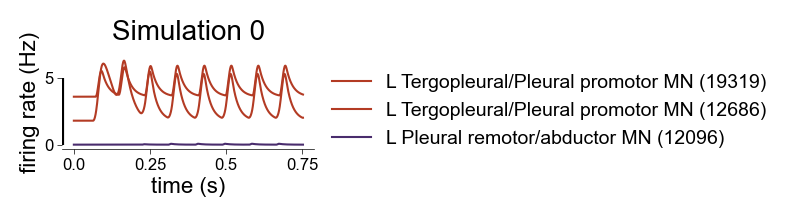

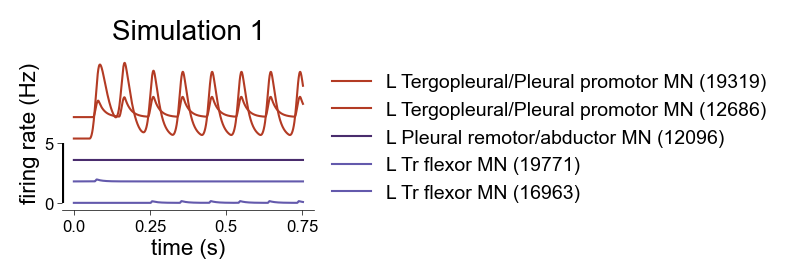

In [7]:
spacer = 3*3/5
scalebar = 5
timeLimit = .75

# Plot both simulation outputs
idx = 0
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

idx = 1
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

# Modify simulations from the command line

Just as we were able to do by creating new configs within a notebook in the first tutorial, we can modify parameters of this config file directly from the command line. This time, we will change the random seed and the stimulus strength.

In [8]:
%run src/run_hydra.py experiment=DNg100_test experiment.seed=2026 experiment.stimI=[350] run_id=tutorial-2-01 paths=starting-paths

Gpu devices: 2
Logging to: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-01/run_hydra.log
Config saved to /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-01/logs/run_config.yaml
Running VNC simulation with the following configuration:
Execution mode: sync, Pruning: False
Created 1 stimulus configurations
Running baseline simulation with:
  1 stimulus configurations
  2 parameter sets
  4604 neurons
  2001 time points
Calculating optimal batch size...
Total simulations to process: 2
System memory: 125.47 GB total, 112.19 GB available
GPU 0: NVIDIA TITAN RTX - 24.0GB
GPU 1: NVIDIA TITAN RTX - 24.0GB
Detected 2 GPU device(s) via nvidia-ml
GPU memory: 24.0GB per device, 48.0GB total
Estimated memory per sample: 326.0 MB
  - Output array: 35.1 MB
  - Intermediate computations: 70.3 MB
  - Weight operations: 80.9 MB
  - Overhead factor: 1.75x
Using GPU memory constraint: 33.60 GB (48GB total)
  Usin

name: DNg100_test
wPath: ${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv
dfPath: ${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv
n_replicates: 2
batch_size: null
dn_screen: false
stimNeurons:
- - 31
removeNeurons: []
keepOnly: []
stimI:
- 350
seed: 2026
saveFigs: true
useTsp: false
save_checkpoints: false
max_pruning_iterations: 200
oscillation_threshold: 0.5



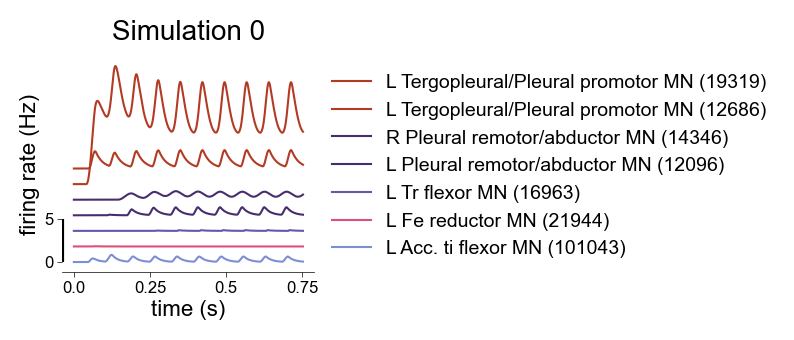

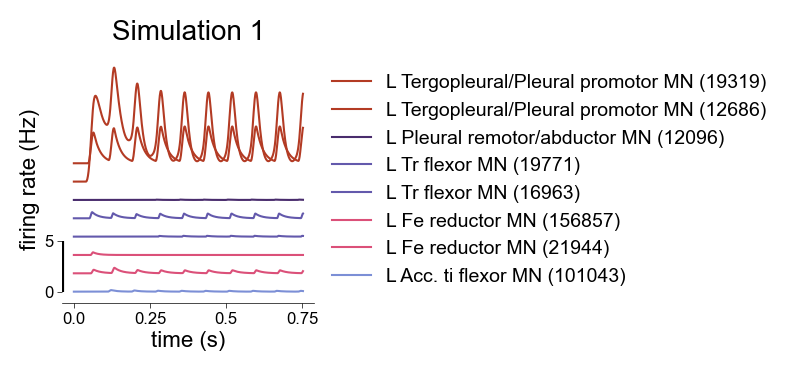

In [9]:
savePath = "data/simulation output/DNg100_test/default/run_id=tutorial-2-01"

# Load the data and configuration
Rs = sparse.load_npz(savePath+f"/ckpt/DNg100_test_Rs.npz").todense()
Rs = Rs[0] # drop the first dimension
cfg = DictConfig(load_from_yaml(savePath+"/logs/run_config.yaml"))
print(OmegaConf.to_yaml(cfg.experiment)) # print the experiment parameters specifically

# Load the connectome data
wTable = pd.read_csv(os.path.relpath(cfg.experiment["dfPath"]))
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

# Plot both simulation outputs
spacer = 3*3/5
scalebar = 5
timeLimit = .75

idx = 0
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

idx = 1
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

## change to a DNb08 simulation
In this example, we'll modify more of the parameters to activate a DNb08 neuron instead. We'll want to change `experiment.name` as well to reflect this change, which will configure it to save in a different directory.

In [10]:
%run src/run_hydra.py experiment=DNg100_test experiment.stimNeurons=[1211] experiment.stimI=[65] experiment.name="DNb08_test" run_id=tutorial-2-02 paths=starting-paths

Gpu devices: 2
Logging to: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNb08_test/default/run_id=tutorial-2-02/run_hydra.log
Config saved to /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNb08_test/default/run_id=tutorial-2-02/logs/run_config.yaml
Running VNC simulation with the following configuration:
Execution mode: sync, Pruning: False
Created 1 stimulus configurations
Running baseline simulation with:
  1 stimulus configurations
  2 parameter sets
  4604 neurons
  2001 time points
Calculating optimal batch size...
Total simulations to process: 2
System memory: 125.47 GB total, 112.26 GB available
GPU 0: NVIDIA TITAN RTX - 24.0GB
GPU 1: NVIDIA TITAN RTX - 24.0GB
Detected 2 GPU device(s) via nvidia-ml
GPU memory: 24.0GB per device, 48.0GB total
Estimated memory per sample: 326.0 MB
  - Output array: 35.1 MB
  - Intermediate computations: 70.3 MB
  - Weight operations: 80.9 MB
  - Overhead factor: 1.75x
Using GPU memory constraint: 33.60 GB (48GB total)
  Using 

name: DNb08_test
wPath: ${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv
dfPath: ${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv
n_replicates: 2
batch_size: null
dn_screen: false
stimNeurons:
- 1211
removeNeurons: []
keepOnly: []
stimI:
- 65
seed: 1
saveFigs: true
useTsp: false
save_checkpoints: false
max_pruning_iterations: 200
oscillation_threshold: 0.5



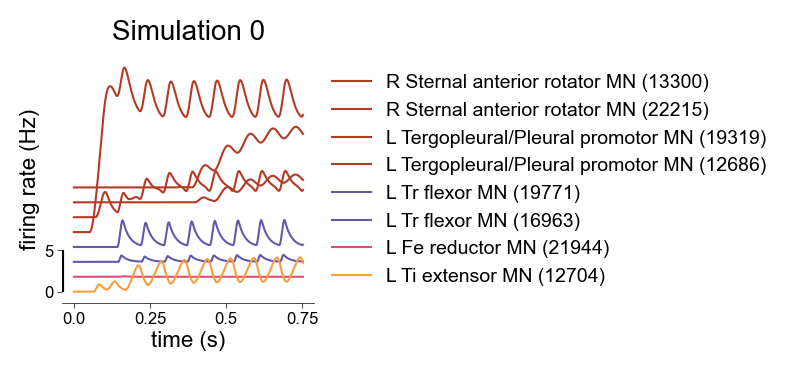

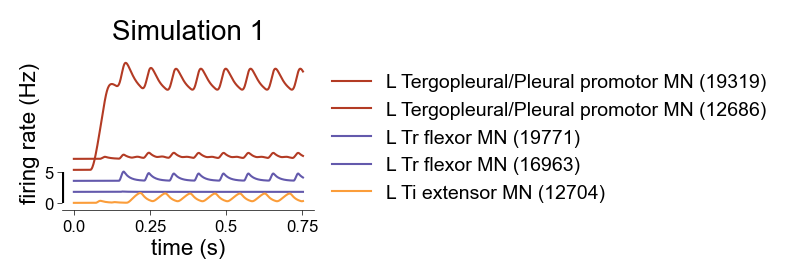

In [11]:
savePath = "data/simulation output/DNb08_test/default/run_id=tutorial-2-02"

# Load the data and configuration
Rs = sparse.load_npz(savePath+f"/ckpt/DNb08_test_Rs.npz").todense()
Rs = Rs[0] # drop the first dimension
cfg = DictConfig(load_from_yaml(savePath+"/logs/run_config.yaml"))
print(OmegaConf.to_yaml(cfg.experiment)) # print the experiment parameters specifically

# Load the connectome data
wTable = pd.read_csv(os.path.relpath(cfg.experiment["dfPath"]))
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

# Plot both simulation outputs
spacer = 3*3/5
scalebar = 5
timeLimit = .75

idx = 0
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

idx = 1
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"Simulation {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

As you can see, this approach worked perfectly well, but the command line arguments are adding up. 

A simpler and more easily-reproducible way would be to create a new `configs/experiment/DNb08_test.yaml` file directly with these new parameters, then run with that as an argument to `experiment` instead.

But either way, you can always see the exact parameters used to configure your simulation in the saved yaml outputs!

# Multirun
Multirun mode lets you run multiple different parameter values, which will save to subdirectories named accordingly. This is specified by a `-m` flag and commas separating different values of the parameter you want to iterate over. In this example, we'll change `removeNeurons` to each of E1, E2, I1, and I2. Specifying a list of configurations for multiple parameters will result in a grid of simulations.


See https://hydra.cc/docs/tutorials/basic/running_your_app/multi-run/ for more information.

In [12]:
%run src/run_hydra.py -m experiment=DNg100_test experiment.removeNeurons=[277],[617],[1167],[86] run_id=tutorial-2-03 paths=starting-paths

Gpu devices: 2
[2026-04-27 21:36:57,512][HYDRA] Launching 4 jobs locally
[2026-04-27 21:36:57,513][HYDRA] 	#0 : experiment=DNg100_test experiment.removeNeurons=[277] run_id=tutorial-2-03 paths=starting-paths
Logging to: /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-03/experiment.removeNeurons=[277]/run_hydra.log
Config saved to /home/smpuglie/Pugliese_cpg_2025/data/simulation output/DNg100_test/default/run_id=tutorial-2-03/experiment.removeNeurons=[277]/logs/run_config.yaml
Running VNC simulation with the following configuration:
Execution mode: sync, Pruning: False
Created 1 stimulus configurations
Initial removal of neurons at indices: [277]
Running Wmask simulation with:
  1 stimulus configurations
  2 parameter sets
  4604 neurons
  2001 time points
Calculating optimal batch size...
Total simulations to process: 2
System memory: 125.47 GB total, 112.22 GB available
GPU 0: NVIDIA TITAN RTX - 24.0GB
GPU 1: NVIDIA TITAN RTX - 24.0GB
Dete

name: DNg100_test
wPath: ${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv
dfPath: ${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv
n_replicates: 2
batch_size: null
dn_screen: false
stimNeurons:
- - 31
removeNeurons:
- 277
keepOnly: []
stimI:
- - 250
seed: 1
saveFigs: true
useTsp: false
save_checkpoints: false
max_pruning_iterations: 200
oscillation_threshold: 0.5



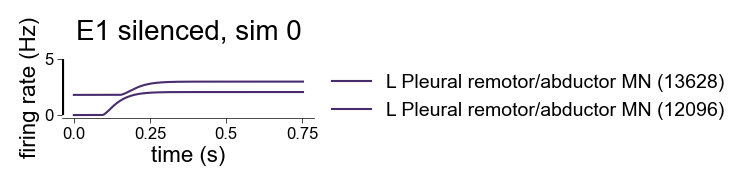

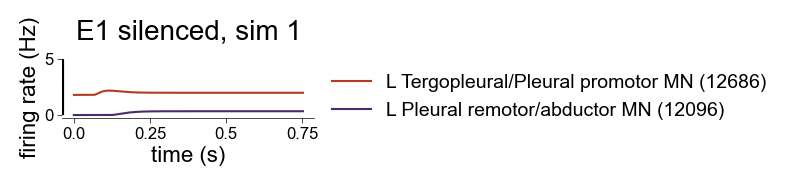

In [13]:
silencedNrn = "E1"  # pick a neuron to plot

###
multirunSavePath = "data/simulation output/DNg100_test/default/run_id=tutorial-2-03"
cpgNrnToIdx = {"E1": 277, "E2": 617, "I1": 1167, "I2": 86}
savePath = f"{multirunSavePath}/experiment.removeNeurons=[{cpgNrnToIdx[silencedNrn]}]"

# Load the data and configuration
Rs = sparse.load_npz(savePath+f"/ckpt/DNg100_test_Rs.npz").todense()
Rs = Rs[0] # drop the first dimension
cfg = DictConfig(load_from_yaml(savePath+"/logs/run_config.yaml"))
print(OmegaConf.to_yaml(cfg.experiment)) # print the experiment parameters specifically

# Load the connectome data
wTable = pd.read_csv(os.path.relpath(cfg.experiment["dfPath"]))
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

# Plot both simulation outputs
spacer = 3*3/5
scalebar = 5
timeLimit = .75

idx = 0
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"{silencedNrn} silenced, sim {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

idx = 1
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"{silencedNrn} silenced, sim {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

name: DNg100_test
wPath: ${paths.data_dir}/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv
dfPath: ${paths.data_dir}/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv
n_replicates: 2
batch_size: null
dn_screen: false
stimNeurons:
- - 31
removeNeurons:
- 1167
keepOnly: []
stimI:
- - 250
seed: 1
saveFigs: true
useTsp: false
save_checkpoints: false
max_pruning_iterations: 200
oscillation_threshold: 0.5



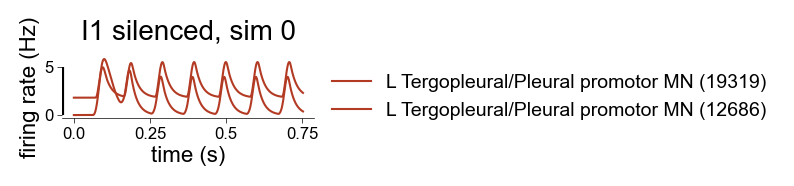

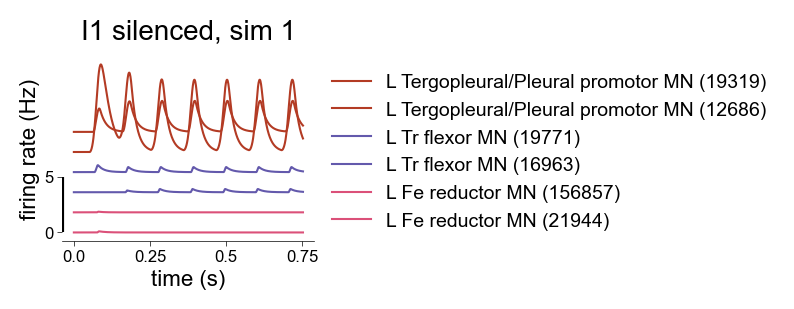

In [14]:
silencedNrn = "I1"  # pick a neuron to plot

###
multirunSavePath = "data/simulation output/DNg100_test/default/run_id=tutorial-2-03"
cpgNrnToIdx = {"E1": 277, "E2": 617, "I1": 1167, "I2": 86}
savePath = f"{multirunSavePath}/experiment.removeNeurons=[{cpgNrnToIdx[silencedNrn]}]"

# Load the data and configuration
Rs = sparse.load_npz(savePath+f"/ckpt/DNg100_test_Rs.npz").todense()
Rs = Rs[0] # drop the first dimension
cfg = DictConfig(load_from_yaml(savePath+"/logs/run_config.yaml"))
print(OmegaConf.to_yaml(cfg.experiment)) # print the experiment parameters specifically

# Load the connectome data
wTable = pd.read_csv(os.path.relpath(cfg.experiment["dfPath"]))
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

# Plot both simulation outputs
spacer = 3*3/5
scalebar = 5
timeLimit = .75

idx = 0
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"{silencedNrn} silenced, sim {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

idx = 1
R = Rs[idx]

fig = plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.xlabel("time (s)")
plt.title(f"{silencedNrn} silenced, sim {idx}")

fig.set_figwidth(1.626)
fig.set_figheight(0.2*len(get_active_data(np.array(R)[mnData.index],mnData)))
fig.set_dpi(200)

plt.show()

**Tip:** as you scale up to larger sets of simulations, you may reach the limit of your system's memory. You can work around this by doing a multirun over two or more `seed` parameters with a decreased `n_replicates`, then concatenating the `R` data during analysis. Adjusting the `batch_size` parameter may also help.

# Going forward
This has covered the workflow of specifying simulations from the command line! yada yada yada